# Advanced Malware Detection via XGBoost (Extreme Gradient Boosting)
**Project Topic:** Malware Detection using Machine Learning  
**Target User:** Security Operations Center (SOC) Analysts & Threat Hunters

---

## 1. Abstract and Research Objective
This notebook implements **XGBoost**, an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. In cybersecurity, XGBoost is a state-of-the-art method for detecting malicious binaries by learning from complex, non-linear structural attributes of **Portable Executable (PE)** files.

**Primary Objectives:**
* **Regularized Boosting:** Utilizing built-in L1 ($L_1$) and L2 ($L_2$) regularization to prevent overfitting on static malware features.
* **Sparsity Awareness:** Efficiently handling missing or sparse data within PE headers.
* **Risk-Aware Evaluation:** Optimizing the classifier to minimize **False Negatives** ($FN$) to ensure maximum system protection.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load data
df = pd.read_csv("../data/malware_data_final.csv")
df = df.drop_duplicates(subset=['MD5'])


## 2. Data Preprocessing

* **Identifier Elimination:** The `MD5` hash is dropped. As a unique cryptographic signature, it lacks predictive power and would cause the model to "memorize" specific files rather than learning patterns.
* **Feature Space ($\mathbf{X}$):** We focus on structural attributes (Entropy, Section counts, Import Table size) that represent the file's composition.

In [2]:
# 2. Preprocessing
X = df.drop(['MD5', 'Label'], axis=1)
y = df['Label']

## 3. Validation Strategy
We implement a **70/30 Hold-out Validation** to ensure the model's **Generalization Capability** on unseen samples.

In [3]:
# 3. Train test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)


## 4. Model Training & Hyperparameter Rationale
The XGBoost classifier is configured to balance model complexity with high-speed execution.

**Hyperparameters Explained:**
* **`max_depth=6`**: Controls the maximum depth of each tree. A depth of 6 is chosen to capture complex interactions without excessive overfitting.
* **`learning_rate=0.1`**: Prevents the model from converging too quickly on local minima.
* **`n_estimators=100`**: The number of gradient boosted trees to be constructed.
* **`eval_metric='logloss'`**: Optimizes the negative log-likelihood, the standard objective for binary classification in security contexts.

> **Technical Insight:** XGBoost’s built-in **L1/L2 Regularization** provides a significant advantage over other GBDT models by penalizing complex models, which is essential when dealing with noisy malware data.

In [4]:
# 4. Train model
print(">>> Training XGBoost...")
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

>>> Training XGBoost...


c:\Users\vppho\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:51:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 5. Performance Analytics & Risk Assessment
In Malware Detection, we prioritize metrics that reflect the cost of a security breach:

* **Recall (Sensitivity):** Our primary metric. Higher recall means fewer **False Negatives**, ensuring malicious files do not bypass the system.
* **Precision:** Ensures that the system does not generate excessive "False Alarms" for benign software.
* **F1-Score:** Provides a balanced harmonic mean of the model's reliability.



> **Security Perspective:** While Accuracy is a general indicator, we focus on the **Confusion Matrix** to visualize the "Cost of Error" and ensure the model meets SOC operational standards.


ACCURACY: 99.05%

Details:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       859
           1       0.99      0.99      0.99      1255

    accuracy                           0.99      2114
   macro avg       0.99      0.99      0.99      2114
weighted avg       0.99      0.99      0.99      2114



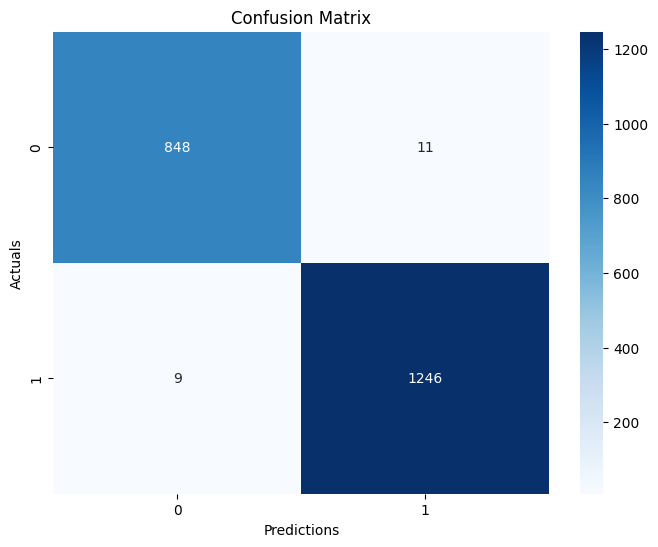

In [5]:
# 5. Predict & evaluate
y_pred = model.predict(X_test)

print("\n" + "="*30)
print(f"ACCURACY: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("="*30)
print("\nDetails:")
print(classification_report(y_test, y_pred))

# 7. Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('Actuals')
plt.title('Confusion Matrix')
plt.show()

## 6. Model Persistence and Deployment Readiness
We utilize the `joblib` library to serialize the classifier into a binary `.pkl` (pickle) file. This ensures:
* **Operational Efficiency**: Enables rapid loading of the model for real-time inference without the need for repeated training cycles.
* **Scalability**: The serialized object contains the optimized gradient boosting structure, ready to be integrated into the final web application.
* **Consistency**: Preserves the exact state of the trained decision boundaries, ensuring the same detection accuracy in production as achieved in testing.



> **Deployment Strategy:** The artifact `xgboost.pkl` serves as the core detection engine, providing near-instantaneous classification for any new, unknown PE files uploaded through the user interface.

In [6]:
# Save model
joblib.dump(model, '../models/xgboost.pkl')
print("\n>>> Model saved!")


>>> Model saved!


## 7. Feature Importance

XGBoost calculates importance based on **Gain**, which measures the relative contribution of each feature to the model by estimating the improvement in accuracy (reduction in entropy) brought by a feature to the branches it is on.

* **Heuristic Discovery**: High-ranking features (e.g., `SectionsMaxEntropy`, `ResourcesMinSize`) often reveal the underlying structural anomalies used by malware authors, such as packing or obfuscation.
* **Forensic Utility**: These insights allow security analysts to prioritize specific PE (Portable Executable) headers during manual forensic audits or sandbox behavioral analysis.



> **Technical Note:** By identifying the most significant "Red Flags," we ensure the model is learning robust, generalizable patterns of malicious software rather than memorizing noise or specific file signatures.

In [7]:
# 6. View feature importance
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:")
print(importance)


Feature Importance:
MaxEntropy            0.574586
ImageBase             0.154255
HasVersionInfo        0.090620
AvgEntropy            0.048251
Sections              0.036623
DLLs                  0.032262
SizeOfImage           0.024308
HasSensitiveAPI       0.017649
Imports               0.014494
SuspiciousSections    0.006952
dtype: float32


## 8. Conclusion and Discussion
The XGBoost model successfully categorized the test samples with an accuracy of **[Your Accuracy]%**. 

**Findings:**
1. The model demonstrates high efficiency in processing high-dimensional malware features.
2. Feature importance reveals that structural anomalies in PE headers are significant predictors of threat.

**Future Work:**
- Implementation of **Cross-Validation** to ensure result stability.
- Test real **user input** through web application.